# Notebook 4 — Action / E-Lz / peri-apo comparison + Sgr stream

This notebook produces three paper figures:

- **Figure 9** (section A): Boötes III vs Typhon vs Local Volume Database
  (LVDB) dwarfs in (action diamond, $L_z$-$E$, $r_{\rm peri}$-$r_{\rm apo}$).
- **Figure 10** (section B): Boötes III vs Typhon vs S5 stream sample in
  the same three panels.
- **Figure 11** (section C): Boötes III fiducial particle-spray model
  (from notebook 2) overlaid on Vasiliev+21 Sgr stream members in
  (Dec, $\mu_\alpha\cos\delta$, $\mu_\delta$, RV, DM) vs RA.

Standalone — no imports from `paper_final/code/`.


## 0 · Setup

In [1]:
import os, time, pickle, warnings
from pathlib import Path
from itertools import cycle
import re

import numpy as np
import pandas as pd
import multiprocess as mp

from scipy.signal import argrelextrema
from astropy import units as u
from astropy.io import fits as afits
from astropy.table import Table

import matplotlib as mpl
import matplotlib.pyplot as plt

from galpy.orbit import Orbit
from galpy.util.conversion import get_physical
from galpy.potential.mwpotentials import McMillan17
from galpy.actionAngle import UnboundError

# ---- Project paths ----
NB_DIR    = Path.cwd().resolve()
PROJ      = NB_DIR.parent
DATA_DIR  = PROJ / "data"
OUT_DIR   = PROJ / "output"
FIG_DIR   = PROJ / "figures"
CACHE_DIR = OUT_DIR / "spray_cache_new6D"

# ---- External catalogues (absolute paths, user's filesystem) ----
TYPHON_FITS = DATA_DIR / "typhoon_in_gaia_dr3.fits"
S5_FITS     = DATA_DIR / "all_streams_DR3_v7_snr5_McMillan17Best.fits"
SGR_DAT     = DATA_DIR / "vasiliev2021_sgr_catalog.dat"
LVDB_URL    = "https://raw.githubusercontent.com/apace7/local_volume_database/main/data/dwarf_mw.csv"

%matplotlib inline
# Canonical paper-figure style — kept identical to notebooks 1, 2, 3.
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300,
    "axes.labelsize": 12, "axes.titlesize": 13, "axes.linewidth": 1.2,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.size": 5, "ytick.major.size": 5,
    "xtick.minor.size": 3, "ytick.minor.size": 3,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.fontsize": 10, "legend.frameon": False,
    "font.family": "serif", "mathtext.fontset": "cm",
})

print(f"Project root  : {PROJ}")
print(f"Typhon fits   : {TYPHON_FITS.exists()}  ({TYPHON_FITS})")
print(f"S5 streams    : {S5_FITS.exists()}  ({S5_FITS})")
print(f"Sgr catalogue : {SGR_DAT.exists()}  ({SGR_DAT})")


Project root  : /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim
Typhon fits   : True  (/Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/data/typhoon_in_gaia_dr3.fits)
S5 streams    : True  (/Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/data/all_streams_DR3_v7_snr5_McMillan17Best.fits)
Sgr catalogue : True  (/Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/data/vasiliev2021_sgr_catalog.dat)


## 1 · Boötes III 6D + helper functions

Pull the systemic 6D from notebook 1's GMM posterior. Define
`actions_energy`, `peri_apo`, and the Roman-numeral fix for dwarf names.


In [2]:
# Boo III: NEW kinematic centre + NEW distance from this work
# (see nb01: iterative-median centroid from 21 GMM members; RRL distance from Garofalo+22)
RA_BOO3, DEC_BOO3 = 209.5567, 26.5529
RA_BOO3_E, DEC_BOO3_E = 0.3, 0.3                    # deg, this work
DIST_BOO3 = 48.47   # 5-RRL G22 mean
DIST_E    = 1.9   # 5-RRL G22 mean (Table 4 of this work; matches App C 6D error budget)

# Pull systemic PM/RV from notebook 1's GMM posterior
samples = pd.read_hdf(OUT_DIR / "boo3_gmm_samples.h5", key="samples")
PMRA_BOO3  = float(samples["pmr_0"].median()); PMRA_E  = float(samples["pmr_0"].std())  or 0.02
PMDEC_BOO3 = float(samples["pmd_0"].median()); PMDEC_E = float(samples["pmd_0"].std())  or 0.01
VEL_BOO3   = float(samples["vhel_0"].median()); VEL_E   = float(samples["vhel_0"].std())  or 0.5

print(f"Boo III systemic (from GMM): pmra={PMRA_BOO3:+.3f} +/-{PMRA_E:.3f}, "
      f"pmdec={PMDEC_BOO3:+.3f} +/-{PMDEC_E:.3f}, "
      f"v_hel={VEL_BOO3:+.2f} +/-{VEL_E:.2f}")

BOO3_P = [RA_BOO3, DEC_BOO3, DIST_BOO3, PMRA_BOO3, PMDEC_BOO3, VEL_BOO3]
BOO3_E = [RA_BOO3_E, DEC_BOO3_E, DIST_E, PMRA_E,    PMDEC_E,    VEL_E]


def fix_roman(name):
    # The LVDB names go through .title() which turns 'iii' -> 'Iii', etc.
    # This regex finds Roman-numeral-shaped tokens and uppercases them.
    return re.sub(r'\b([IVX][ivx]+)\b', lambda m: m.group(0).upper(), name)


def actions_energy(p6, errs=None, num=0):
    if errs is not None and num > 0:
        ps = np.random.normal(loc=p6, scale=np.array(errs), size=(num, 6))
    else:
        ps = np.atleast_2d(p6)
    try:
        o = Orbit(ps, radec=True, **get_physical(McMillan17))
        Jr = np.atleast_1d(o.jr(pot=McMillan17))
        Jp = np.atleast_1d(o.jp(pot=McMillan17))
        Jz = np.atleast_1d(o.jz(pot=McMillan17))
        Lz = np.atleast_1d(o.Lz())
        E  = np.atleast_1d(o.E(pot=McMillan17))
        mask = np.isfinite(Jr) & np.isfinite(Jp) & np.isfinite(Jz) & np.isfinite(E)
        return np.array([Jr[mask], Lz[mask], Jz[mask]]), E[mask]
    except (UnboundError, ValueError):
        return np.array([[], [], []]), np.array([])


TS_PERI = np.linspace(0, 10, 1001) * u.Gyr


def peri_apo(p6, errs=None, num=0):
    if errs is not None and num > 0:
        ps = np.random.normal(loc=p6, scale=np.array(errs), size=(num, 6))
    else:
        ps = np.atleast_2d(p6)
    try:
        o = Orbit(ps, radec=True, **get_physical(McMillan17))
        o.integrate(-TS_PERI, McMillan17)
        r = np.atleast_2d(o.r(-TS_PERI))
    except (UnboundError, ValueError):
        return np.array([]), np.array([])
    pe, ap = [], []
    for i in range(r.shape[0]):
        ri = r[i]
        if not np.all(np.isfinite(ri)):
            continue
        lo = argrelextrema(ri, np.less)[0]
        hi = argrelextrema(ri, np.greater)[0]
        if len(lo) and len(hi):
            pe.append(float(ri[lo[0]])); ap.append(float(ri[hi[0]]))
    return np.array(pe), np.array(ap)


def plot_diamond(axi, acts, text="", **kw):
    if acts.size == 0: return
    Jtot = np.abs(acts[0]) + np.abs(acts[1]) + np.abs(acts[2])
    x = acts[1] / Jtot; y = (acts[2] - acts[0]) / Jtot
    mask = np.isfinite(x) & np.isfinite(y); x, y = x[mask], y[mask]
    if len(x) == 0: return
    mx, my = np.median(x), np.median(y)
    axi.scatter(x, y, rasterized=True, **kw)
    axi.plot(mx, my, "o", ms=4, c=kw.get("c", "k"), mec="k")
    if text:
        axi.text(mx, my - 0.05, text, ha="center", va="center",
                  c=kw.get("c", "k"), fontsize=8, fontweight="bold")


Boo III systemic (from GMM): pmra=-1.162 +/-0.018, pmdec=-0.883 +/-0.013, v_hel=+191.22 +/-0.85


## 2 · Section A — Figure 9 (Boo III vs Typhon vs LVDB dwarfs)

Action diamond + $L_z$-$E$ + peri-apo for Local Volume MW dwarfs, with
Boötes III highlighted in red and Typhon as black stars. Uses
McMillan17 throughout, 100 Monte-Carlo realisations per dwarf (sampled
from the LVDB published 6D errors).


In [3]:
MC_N_DWARF = 50
NB4_CACHE_DIR = OUT_DIR / "nb4_cache"; NB4_CACHE_DIR.mkdir(exist_ok=True)
TYPHON_PKL = NB4_CACHE_DIR / "typhon_actions.pkl"

# ---- Typhon actions (cached; depends only on the Gaia DR3 catalog) ----
if TYPHON_PKL.exists():
    print(f"Loading cached Typhon actions from {TYPHON_PKL.name}")
    with open(TYPHON_PKL, "rb") as f:
        c = pickle.load(f)
    typ_acts = c["actions"]; typ_E = c["energies"]
    typ_peri = c["peris"]; typ_apo = c["apos"]
    print(f"  {typ_acts.shape[1]} Typhon stars")
else:
    print("Loading Typhon catalogue ...")
    with afits.open(TYPHON_FITS) as h:
        typh = Table(h[1].data)
    typh["dist_kpc"] = typh["dist_by_parallax"] / 1000.0
    typ_acts = [[], [], []]; typ_E = []; typ_peri = []; typ_apo = []
    for row in typh:
        p = [row["ra"], row["dec"], row["dist_kpc"],
             row["pmra"], row["pmdec"], row["radial_velocity"]]
        if not np.all(np.isfinite(p)) or row["dist_kpc"] <= 0 or row["dist_kpc"] > 200:
            continue
        a, E = actions_energy(p); pe, ap = peri_apo(p)
        if a.shape[1] == 0 or pe.size == 0:
            continue
        typ_acts[0].extend(a[0]); typ_acts[1].extend(a[1]); typ_acts[2].extend(a[2])
        typ_E.append(E[0]); typ_peri.append(pe[0]); typ_apo.append(ap[0])
    typ_acts = np.array(typ_acts); typ_E = np.array(typ_E)
    typ_peri = np.array(typ_peri); typ_apo = np.array(typ_apo)
    with open(TYPHON_PKL, "wb") as f:
        pickle.dump({"actions": typ_acts, "energies": typ_E,
                     "peris": typ_peri, "apos": typ_apo}, f)
    print(f"  {typ_acts.shape[1]} Typhon stars  (cached -> {TYPHON_PKL.name})")

# ---- Boo III actions (always recomputed: 6D depends on NB1 GMM) ----
print("Boo III ...")
boo_a, boo_E       = actions_energy(BOO3_P, BOO3_E, MC_N_DWARF)
boo_peri, boo_apo  = peri_apo(BOO3_P, BOO3_E, MC_N_DWARF)
print(f"  {boo_a.shape[1]} samples")

# ---- LVDB dwarf jobs (catalog-only, deterministic; just build the job list) ----
print("Loading LVDB ...")
lvdb = Table.read(LVDB_URL).to_pandas()
need = ["ra", "dec", "distance", "pmra", "pmdec", "vlos_systemic",
        "distance_em", "distance_ep", "pmra_em", "pmra_ep",
        "pmdec_em", "pmdec_ep", "vlos_systemic_em", "vlos_systemic_ep"]
for c in need:
    lvdb[c] = pd.to_numeric(lvdb[c], errors="coerce")
ok = lvdb[need[:6]].notna().all(axis=1)
print(f"  {ok.sum()} / {len(lvdb)} dwarfs with full 6D")

dwarf_jobs = []
for _, row in lvdb[ok].iterrows():
    key = row["key"]
    if key == "bootes_3":
        continue
    d_err = np.nanmean([row["distance_em"], row["distance_ep"]])
    pmra_err = np.nanmean([row["pmra_em"], row["pmra_ep"]])
    pmdec_err = np.nanmean([row["pmdec_em"], row["pmdec_ep"]])
    vlos_err = np.nanmean([row["vlos_systemic_em"], row["vlos_systemic_ep"]])
    if not np.isfinite(d_err): d_err = row["distance"] * 0.05
    if not np.isfinite(pmra_err): pmra_err = 0.05
    if not np.isfinite(pmdec_err): pmdec_err = 0.05
    if not np.isfinite(vlos_err): vlos_err = 2.0
    p = [row["ra"], row["dec"], row["distance"],
         row["pmra"], row["pmdec"], row["vlos_systemic"]]
    e = [0, 0, d_err, pmra_err, pmdec_err, vlos_err]
    name_raw = str(row.get("name", key)).replace("_", " ").title()
    name = fix_roman(name_raw)
    dwarf_jobs.append((name, p, e))

print(f"  {len(dwarf_jobs)} dwarfs to process")


Loading cached Typhon actions from typhon_actions.pkl
  16 Typhon stars
Boo III ...
/opt/homebrew/Caskroom/miniforge/base/envs/myenv/lib/python3.12/site-packages/galpy/potential/SCFPotential.py:534: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  out = numpy.divide((r / a - 1.0), (r / a + 1.0), where=True ^ numpy.isinf(r))



  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:00<00:14,  3.46it/s]

  8%|▊         | 4/50 [00:00<00:03, 12.07it/s]

 18%|█▊        | 9/50 [00:00<00:01, 35.83it/s]

...

 62%|██████▏   | 31/50 [00:01<00:00, 33.21it/s]

 84%|████████▍ | 42/50 [00:01<00:00, 47.92it/s]

 98%|█████████▊| 49/50 [00:01<00:00, 41.79it/s]

  50 samples
Loading LVDB ...


  55 / 67 dwarfs with full 6D
  54 dwarfs to process


In [4]:
def _process_dwarf(args):
    name, p, e = args
    a, E = actions_energy(p, e, MC_N_DWARF)
    pe, ap = peri_apo(p, e, MC_N_DWARF)
    if a.shape[1] < 5 or pe.size < 5:
        return (name, None)
    return (name, dict(actions=a, energies=E, peris=pe, apos=ap))


DWARF_PKL = NB4_CACHE_DIR / f"lvdb_dwarfs_actions_mc{MC_N_DWARF}.pkl"
if DWARF_PKL.exists():
    print(f"Loading cached LVDB dwarf actions from {DWARF_PKL.name}")
    with open(DWARF_PKL, "rb") as f:
        c = pickle.load(f)
    dw_a    = c["actions"]
    dw_E    = c["energies"]
    dw_peri = c["peris"]
    dw_apo  = c["apos"]
    print(f"  {len(dw_a)} dwarfs loaded from cache (MC_N_DWARF={MC_N_DWARF})")
else:
    t0 = time.time()
    print(f"Computing actions/peri/apo for {len(dwarf_jobs)} dwarfs "
          f"(sequential, expect ~{len(dwarf_jobs)*MC_N_DWARF*0.04:.0f} min) ...")
    results = [_process_dwarf(j) for j in dwarf_jobs]
    dw_a = {}; dw_E = {}; dw_peri = {}; dw_apo = {}
    for name, r in results:
        if r is None: continue
        dw_a[name] = r["actions"]; dw_E[name] = r["energies"]
        dw_peri[name] = r["peris"]; dw_apo[name] = r["apos"]
    print(f"  -> {len(dw_a)} dwarfs done in {(time.time()-t0)/60:.1f} min")
    with open(DWARF_PKL, "wb") as f:
        pickle.dump({"actions": dw_a, "energies": dw_E,
                     "peris": dw_peri, "apos": dw_apo,
                     "mc_n_dwarf": MC_N_DWARF, "potential": "McMillan17"}, f)
    print(f"  cached -> {DWARF_PKL.name}")


Loading cached LVDB dwarf actions from lvdb_dwarfs_actions_mc50.pkl
  45 dwarfs loaded from cache (MC_N_DWARF=50)


Plotting Fig 8 ...


Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/fig9_typhon_dwarfs.pdf


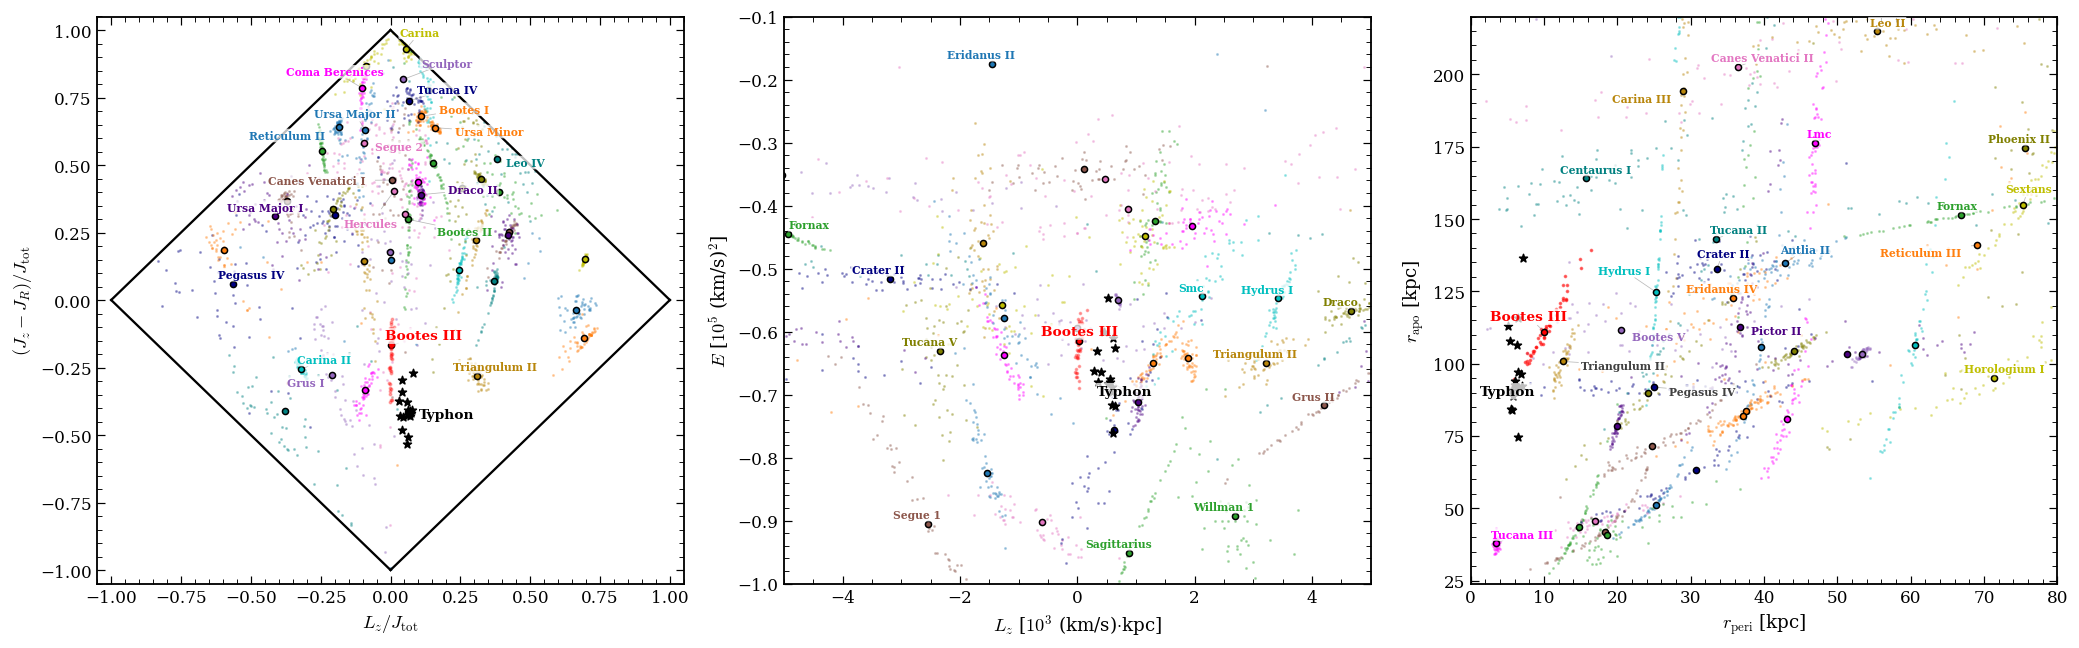

In [5]:
print("Plotting Fig 8 ...")

# --- Smart-distributed labels for fig 9 ---
# For each dwarf, decide which of the 3 panels has the most room for its
# label, and place the label there only.  Each dwarf is labelled exactly
# once across the figure.  Boo III + Typhon get all three panels.
PANEL_AXES_SPANS = [(2.0, 2.0), (10.0, 1.0), (80.0, 200.0)]   # (sx, sy) per panel
PANEL_BASE_YOFF  = [0.04, 0.025, 0.03]                          # normalised y-offset
_placed_panels = [[], [], []]   # legacy, kept for any other refs
from adjustText import adjust_text
_fig9_texts = [[], [], []]      # per-panel Text artists for adjustText
_fig9_anchors = [[], [], []]    # per-panel marker (x, y) anchors

def _crowdedness(x, y, placed, sx, sy):
    """Number of previously-placed labels within a small radius of (x, y),
    measured in axis-span-normalised distance."""
    if not placed: return 0
    return sum(1 for px, py in placed
               if abs(x-px)/sx < 0.07 and abs(y-py)/sy < 0.07)

def _smart_place(ax, x, y, name, placed, sx, sy, base_yoff_norm,
                  color, fontsize, fontweight, bbox=None,
                  extra_anchors=(), x_range=None, y_range=None):
    """Aggressive label placement (matches the v variant in cell 11).
    Tries a dense grid of horizontal+vertical shifts; horizontal hops
    can reach empty regions several panel-units away when the local
    cluster is dense."""
    base_y = base_yoff_norm * sy
    base_x = base_yoff_norm * sx * 2.0
    trials = [
        (0.0,    +1.0, "center"),
        (0.0,    -1.4, "center"),
        (+1.5,    0.0, "left"),
        (-1.5,    0.0, "right"),
        (+1.5,   +0.6, "left"),
        (-1.5,   +0.6, "right"),
        (+1.5,   -0.9, "left"),
        (-1.5,   -0.9, "right"),
        (0.0,    +2.2, "center"),
        (0.0,    -2.4, "center"),
        (+3.0,    0.0, "left"),
        (-3.0,    0.0, "right"),
        (+5.0,    0.0, "left"),
        (-5.0,    0.0, "right"),
        (+8.0,    0.0, "left"),
        (-8.0,    0.0, "right"),
    ]
    chosen = None
    for dx_n, dy_n, ha in trials:
        nx = x + dx_n * base_x
        ny = y + dy_n * base_y
        if x_range is not None and not (x_range[0] <= nx <= x_range[1]):
            continue
        if y_range is not None and not (y_range[0] <= ny <= y_range[1]):
            continue
        too_close = False
        for (px, py) in placed:
            if abs(nx-px)/sx < 0.05 and abs(ny-py)/sy < 0.030:
                too_close = True; break
        if not too_close:
            for (px, py) in extra_anchors:
                if abs(nx-px)/sx < 0.040 and abs(ny-py)/sy < 0.025:
                    too_close = True; break
        if not too_close:
            chosen = (nx, ny, ha); break
    if chosen is None:
        chosen = (x, y + base_y, "center")
    nx, ny, ha = chosen
    ax.text(nx, ny, name, ha=ha, c=color, fontsize=fontsize,
            fontweight=fontweight, clip_on=True, bbox=bbox, zorder=20)
    placed.append((nx, ny))


def _action_diamond_xy(acts):
    """Replicate plot_diamond's mapping to compute (Lz/Jtot, (Jz-JR)/Jtot) median."""
    if acts.size == 0: return (np.nan, np.nan)
    Jtot = np.abs(acts[0]) + np.abs(acts[1]) + np.abs(acts[2])
    x = acts[1] / Jtot; y = (acts[2] - acts[0]) / Jtot
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() == 0: return (np.nan, np.nan)
    return (float(np.median(x[mask])), float(np.median(y[mask])))


# Pre-compute every dwarf's panel-2 (rperi, rapo) position so we can decide
# which dwarfs get the "high-apo sparse region" preference: any dwarf with
# rapo > 110 kpc OR with no other dwarf within (10 kpc, 25 kpc) gets labelled
# in panel 2 first; the rest go through the least-crowded-panel logic.
_panel2_positions = {}
for _n in dw_a:
    _panel2_positions[_n] = (float(np.median(dw_peri[_n])), float(np.median(dw_apo[_n])))
def _is_sparse_in_panel2(name):
    mx, my = _panel2_positions[name]
    if not (0 < mx < 80 and 24 < my < 220):
        return False
    if my > 110:
        return True
    n_nearby = 0
    for other, (ox, oy) in _panel2_positions.items():
        if other == name: continue
        if abs(mx - ox) < 10 and abs(my - oy) < 25:
            n_nearby += 1
    return n_nearby == 0


# Cache (Lz, E) coords too so we can detect sparse regions in the middle panel.
_panel1_positions = {}
for _n in dw_a:
    _panel1_positions[_n] = (float(np.median(dw_a[_n][1] / 1e3)),
                              float(np.median(dw_E[_n] / 1e5)))
def _is_sparse_in_panel1(name):
    """True if this dwarf sits in a sparse region of (Lz, E):
    far from other dwarfs (no neighbour within Δ=1.2 in Lz, 0.10 in E),
    OR at the extreme left/right of the panel (|Lz| > 2.0)."""
    mx, my = _panel1_positions[name]
    if not (-5 < mx < 5 and -1 < my < 0):
        return False
    if abs(mx) > 2.0:
        return True
    n_nearby = 0
    for other, (ox, oy) in _panel1_positions.items():
        if other == name: continue
        if abs(mx - ox) < 1.2 and abs(my - oy) < 0.10:
            n_nearby += 1
    return n_nearby == 0


# Panel 0 sparse check (action diamond).
_panel0_positions = {}
for _n in dw_a:
    _Jt = np.abs(dw_a[_n][0]) + np.abs(dw_a[_n][1]) + np.abs(dw_a[_n][2])
    _x = dw_a[_n][1] / _Jt; _y = (dw_a[_n][2] - dw_a[_n][0]) / _Jt
    _m = np.isfinite(_x) & np.isfinite(_y)
    if _m.sum() == 0:
        _panel0_positions[_n] = (np.nan, np.nan)
    else:
        _panel0_positions[_n] = (float(np.median(_x[_m])), float(np.median(_y[_m])))
def _is_sparse_in_panel0(name):
    mx, my = _panel0_positions[name]
    if not (np.isfinite(mx) and -1 < mx < 1 and -1 < my < 1):
        return False
    n_nearby = 0
    for other, (ox, oy) in _panel0_positions.items():
        if other == name: continue
        if abs(mx - ox) < 0.20 and abs(my - oy) < 0.20:
            n_nearby += 1
    return n_nearby == 0


# Pre-compute every dwarf's marker centroid for panels 1 and 2 so labels
# can avoid covering markers, not just other labels.
_marker_xy_panel1 = []
_marker_xy_panel2 = []
for _n in dw_a:
    _marker_xy_panel1.append((float(np.median(dw_a[_n][1]/1e3)),
                               float(np.median(dw_E[_n]/1e5))))
    _marker_xy_panel2.append((float(np.median(dw_peri[_n])),
                               float(np.median(dw_apo[_n]))))


_label_idx = 0
fig, ax = plt.subplots(1, 3, figsize=(19, 6))
dotsize = 4
alpha = 0.3
# Excluding tab:red (Boo III's colour) and tab:gray/black (Typhon's) so
# no dwarf gets confused with the two highlighted reference objects.
colors = cycle(["tab:blue", "tab:orange", "tab:green", "tab:purple",
                "tab:brown", "tab:pink", "y", "c", "darkgoldenrod",
                "teal", "magenta", "navy", "olive", "indigo"])
# White bbox to make labels stand out — matches the Fig 10 style.
_dwarf_bbox = dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.75)

for side in [([-1, 0], [0, -1]), ([0, 1], [-1, 0]), ([1, 0], [0, 1]), ([0, -1], [1, 0])]:
    ax[0].plot(side[0], side[1], c="k", zorder=2)
ax[0].set_xlabel(r"$L_z / J_{\rm tot}$")
ax[0].set_ylabel(r"$(J_z - J_R) / J_{\rm tot}$")

# Boo III + Typhon centres in the (Lz, E) and (peri, apo) panels — used to
# decide which dwarfs get text labels in panels 1 and 2 (panel 0 labels all).
_boo_lz, _boo_e   = float(np.median(boo_a[1]/1e3)), float(np.median(boo_E/1e5))
_boo_pe, _boo_ap  = float(np.median(boo_peri)),     float(np.median(boo_apo))
_typ_lz = typ_acts[1]/1e3 if typ_acts.size > 0 else np.array([])
_typ_e  = typ_E/1e5      if typ_acts.size > 0 else np.array([])
_typ_pe = typ_peri       if typ_acts.size > 0 else np.array([])
_typ_ap = typ_apo        if typ_acts.size > 0 else np.array([])

# Normalised-distance thresholds (unitless, scaled by the panel's axis span).
def _near(x, y, anchors_x, anchors_y, sx, sy, thresh=0.12):
    """Return True if (x, y) is within `thresh` of any anchor in the
    panel's normalised coords (axis-span normalised)."""
    if len(anchors_x) == 0: return False
    d = np.hypot((x - np.asarray(anchors_x)) / sx,
                 (y - np.asarray(anchors_y)) / sy)
    return float(d.min()) < thresh

# Stagger label vertical offset so adjacent labels don't all stack up.
# Pre-compute every dwarf's marker centroid for panels 1 and 2 so labels
# can avoid covering markers, not just other labels.
_marker_xy_panel1 = []
_marker_xy_panel2 = []
for _n in dw_a:
    _marker_xy_panel1.append((float(np.median(dw_a[_n][1]/1e3)),
                               float(np.median(dw_E[_n]/1e5))))
    _marker_xy_panel2.append((float(np.median(dw_peri[_n])),
                               float(np.median(dw_apo[_n]))))


_label_idx = 0
for name in dw_a:
    clr = next(colors)
    # Panel 0: scatter + median dot, NO text (label distributed below).
    plot_diamond(ax[0], dw_a[name], text="", c=clr, marker=".", s=4, alpha=alpha, zorder=1)
    # Panel 1 scatter + median.
    xlz = dw_a[name][1] / 1e3; yE = dw_E[name] / 1e5
    ax[1].scatter(xlz, yE, c=clr, alpha=alpha, marker=".", s=4, rasterized=True)
    mx1, my1 = float(np.median(xlz)), float(np.median(yE))
    ax[1].plot(mx1, my1, "o", ms=dotsize, c=clr, mec="k")
    # Panel 2 scatter + median.
    xp, ya = dw_peri[name], dw_apo[name]
    ax[2].scatter(xp, ya, c=clr, alpha=alpha, marker=".", s=4, rasterized=True)
    mx2, my2 = float(np.median(xp)), float(np.median(ya))
    ax[2].plot(mx2, my2, "o", ms=dotsize, c=clr, mec="k")
    # Panel 0 position (action diamond).
    mx0, my0 = _action_diamond_xy(dw_a[name])
    panel_xy = [(mx0, my0), (mx1, my1), (mx2, my2)]
    panel_in_range = [
        np.isfinite(mx0) and -1 < mx0 < 1 and -1 < my0 < 1,
        -5 < mx1 < 5 and -1 < my1 < 0,
        0 < mx2 < 80 and 24 < my2 < 220,
    ]
    # Phase 1: label in EVERY panel where this dwarf sits in a sparse region
    # (so isolated points are never missed).  Each dwarf may end up labelled
    # in one, two, or three panels depending on its phase-space position.
    sparse_panels = []
    if _is_sparse_in_panel0(name) and panel_in_range[0]:
        sparse_panels.append(0)
    if _is_sparse_in_panel1(name) and panel_in_range[1]:
        sparse_panels.append(1)
    if _is_sparse_in_panel2(name) and panel_in_range[2]:
        sparse_panels.append(2)

    if sparse_panels:
        chosen_list = sparse_panels
    else:
        # Phase 2: pick the single least-crowded panel for this dwarf.
        crowd = []
        for pi in range(3):
            if not panel_in_range[pi]:
                crowd.append(10**6)
            else:
                sx, sy = PANEL_AXES_SPANS[pi]
                crowd.append(_crowdedness(panel_xy[pi][0], panel_xy[pi][1],
                                           _placed_panels[pi], sx, sy))
        if min(crowd) >= 10**6:
            _label_idx += 1; continue
        chosen_list = [int(np.argmin(crowd))]

    for chosen in chosen_list:
        _xx, _yy = panel_xy[chosen]
        _t = ax[chosen].text(_xx, _yy, name, ha="center", c=clr,
                             fontsize=7, fontweight="bold", clip_on=True,
                             bbox=_dwarf_bbox, zorder=20)
        _fig9_texts[chosen].append(_t)
        _fig9_anchors[chosen].append((_xx, _yy))
    _label_idx += 1

# Boo III (red)
plot_diamond(ax[0], boo_a, text="", c="red", marker=".", s=10, alpha=alpha, zorder=3)
_boo_diamond_xy = _action_diamond_xy(boo_a)
_placed_panels[0].append((_boo_diamond_xy[0], _boo_diamond_xy[1]))
_t_boo0 = ax[0].text(_boo_diamond_xy[0], _boo_diamond_xy[1], "Bootes III",
           ha="center", c="red", fontweight="bold", fontsize=9, clip_on=True,
           bbox=_dwarf_bbox, zorder=22)
_fig9_texts[0].append(_t_boo0); _fig9_anchors[0].append((_boo_diamond_xy[0], _boo_diamond_xy[1]))
ax[1].scatter(boo_a[1]/1e3, boo_E/1e5, c="red", marker=".", alpha=alpha, s=8)
mx, my = np.median(boo_a[1]/1e3), np.median(boo_E/1e5)
ax[1].plot(mx, my, "o", ms=dotsize, c="red", mec="k")
_t_boo1 = ax[1].text(mx, my, "Bootes III", ha="center", c="red", fontweight="bold", fontsize=9, clip_on=True, bbox=_dwarf_bbox, zorder=22); _fig9_texts[1].append(_t_boo1); _fig9_anchors[1].append((mx, my))
ax[2].scatter(boo_peri, boo_apo, c="red", marker=".", alpha=0.5, s=8)
mx, my = np.median(boo_peri), np.median(boo_apo)
ax[2].plot(mx, my, "o", ms=dotsize, c="red", mec="k")
_t_boo2 = ax[2].text(mx, my, "Bootes III", ha="center", c="red", fontweight="bold", fontsize=9, clip_on=True, bbox=_dwarf_bbox, zorder=22); _fig9_texts[2].append(_t_boo2); _fig9_anchors[2].append((mx, my))

# Typhon (black stars) — label the stream centroid in each panel.
if typ_acts.size > 0:
    plot_diamond(ax[0], typ_acts, c="k", marker="*", s=30, zorder=3, text="")
    ax[1].scatter(typ_acts[1]/1e3, typ_E/1e5, c="k", marker="*", s=30, zorder=3, label="Typhon")
    ax[2].scatter(typ_peri, typ_apo, c="k", marker="*", s=30, zorder=3)
    # Centroids
    _typ0_xy = _action_diamond_xy(typ_acts)
    _typ1_x, _typ1_y = float(np.median(typ_acts[1]/1e3)), float(np.median(typ_E/1e5))
    _typ2_x, _typ2_y = float(np.median(typ_peri)),       float(np.median(typ_apo))
    # Place "Typhon" labels (bold black, slightly larger) in all 3 panels.
    for _pi, (_tx, _ty) in [(0, _typ0_xy), (1, (_typ1_x, _typ1_y)), (2, (_typ2_x, _typ2_y))]:
        if not np.isfinite(_tx): continue
        _t_typ = ax[_pi].text(_tx, _ty, "Typhon", ha="center", c="k",
                              fontweight="bold", fontsize=9, clip_on=True, zorder=22,
                              bbox=_dwarf_bbox)
        _fig9_texts[_pi].append(_t_typ); _fig9_anchors[_pi].append((_tx, _ty))

ax[0].set_xlim(-1.05, 1.05); ax[0].set_ylim(-1.05, 1.05)
ax[1].set_xlabel(r"$L_z$ [$10^3$ (km/s)$\cdot$kpc]")
ax[1].set_ylabel(r"$E$ [$10^5$ (km/s)$^2$]")
ax[1].set_xlim(-5, 5); ax[1].set_ylim(-1, -0.1)
ax[2].set_xlabel(r"$r_{\rm peri}$ [kpc]")
ax[2].set_ylabel(r"$r_{\rm apo}$ [kpc]")
ax[2].set_xlim(0, 80); ax[2].set_ylim(24, 220)

# Force-label any dwarf within 25 kpc of Boo III in (peri, apo) directly
# in panel 2, so the right-panel "yellow circle near Boo III" gets a name
# even if the distribute-once logic placed it in another panel.
_boo_pe, _boo_ap = float(np.median(boo_peri)), float(np.median(boo_apo))
for _n in dw_a:
    _xp = float(np.median(dw_peri[_n])); _ya = float(np.median(dw_apo[_n]))
    if not (0 < _xp < 80 and 24 < _ya < 220): continue
    if np.hypot(_xp - _boo_pe, _ya - _boo_ap) < 25.0:
        # Skip if already labelled in panel 2
        already = any(abs(_xp - ax_pos[0]) < 0.5 and abs(_ya - ax_pos[1]) < 0.5
                       for ax_pos in _fig9_anchors[2])
        if already: continue
        # Look up this dwarf's colour by re-creating the cycle iteration
        # — easier: use a neutral darkblue/darkred so the extra label
        # doesn't confuse colour assignments.
        _t_force = ax[2].text(_xp, _ya, _n, ha="center", c="0.25",
                               fontsize=7, fontweight="bold", clip_on=True,
                               bbox=_dwarf_bbox, zorder=21)
        _fig9_texts[2].append(_t_force)
        _fig9_anchors[2].append((_xp, _ya))

# Repulsion-based label placement (adjustText) per panel.  Each panel's
# labels are pushed off each other and off the marker positions of all
# dwarfs in that panel, with a faint leader line if the label has to
# move far.
import numpy as _np
def _xy_arr(pairs):
    if not pairs: return None, None
    a = _np.asarray(pairs); return a[:, 0], a[:, 1]
for _pi in range(3):
    if not _fig9_texts[_pi]: continue
    _ax_x, _ax_y = _xy_arr(_fig9_anchors[_pi])
    adjust_text(_fig9_texts[_pi], x=_ax_x, y=_ax_y, ax=ax[_pi],
                force_text=(0.4, 0.6), force_static=(0.5, 0.6),
                expand=(1.15, 1.30),
                arrowprops=dict(arrowstyle="-", color="0.55", lw=0.5, alpha=0.6))

plt.tight_layout()
out_pdf = FIG_DIR / "fig9_typhon_dwarfs.pdf"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
print(f"Saved {out_pdf}")
plt.show()


## 3 · Section B — Figure 10 (Boo III vs Typhon vs S5 streams)


In [6]:
STREAMS_PKL = NB4_CACHE_DIR / "s5_streams_actions.pkl"
if STREAMS_PKL.exists():
    print(f"Loading cached S5 streams actions from {STREAMS_PKL.name}")
    with open(STREAMS_PKL, "rb") as f:
        stream_data = pickle.load(f)
    print(f"  {len(stream_data)} streams loaded from cache")
else:
    print("Loading S5 streams ...")
    with afits.open(S5_FITS) as h:
        st = Table(h[1].data)
    dist = 10 ** (st["dm"].astype(float) / 5.0 - 2.0)
    ra = np.asarray(st["ra"]); dec = np.asarray(st["dec"])
    pmra_s = np.asarray(st["pmra"]); pmdec_s = np.asarray(st["pmdec"])
    vel = np.asarray(st["vel_calib"])
    region = np.asarray([str(v) for v in st["regionname"]])
    ok = (np.isfinite(ra) & np.isfinite(dec) & np.isfinite(dist) & (dist > 0) & (dist < 300)
          & np.isfinite(pmra_s) & np.isfinite(pmdec_s) & np.isfinite(vel))
    if "good_star_pb" in st.colnames:
        ok &= (np.asarray(st["good_star_pb"]) > 0.5)
    print(f"  {ok.sum()} / {len(st)} stars with full 6D + good_star_pb > 0.5")

    stream_jobs = []
    for rn in np.unique(region[ok]):
        idx = np.where(ok & (region == rn))[0]
        if len(idx) < 3: continue
        stars = [[float(ra[i]), float(dec[i]), float(dist[i]),
                  float(pmra_s[i]), float(pmdec_s[i]), float(vel[i])] for i in idx]
        stream_jobs.append((rn, stars))
    print(f"  {len(stream_jobs)} streams to process ({sum(len(s[1]) for s in stream_jobs)} stars total)")

    stream_data = {}
    t0 = time.time()
    for name, stars in stream_jobs:
        acts = [[], [], []]; Es = []; peris = []; apos = []
        for p in stars:
            a, E = actions_energy(p); pe, ap = peri_apo(p)
            if a.shape[1] == 0 or pe.size == 0 or ap.size == 0:
                continue
            acts[0].extend(a[0]); acts[1].extend(a[1]); acts[2].extend(a[2])
            Es.extend(E); peris.extend(pe); apos.extend(ap)
        if len(Es) < 3:
            continue
        stream_data[name] = dict(actions=np.array(acts), energies=np.array(Es),
                                  peris=np.array(peris), apos=np.array(apos))
    print(f"  {len(stream_data)} streams done in {time.time()-t0:.1f}s")
    with open(STREAMS_PKL, "wb") as f:
        pickle.dump(stream_data, f)
    print(f"  cached -> {STREAMS_PKL.name}")


Loading cached S5 streams actions from s5_streams_actions.pkl
  14 streams loaded from cache


Plotting Fig 9 ...


Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/fig10_typhon_streams.pdf


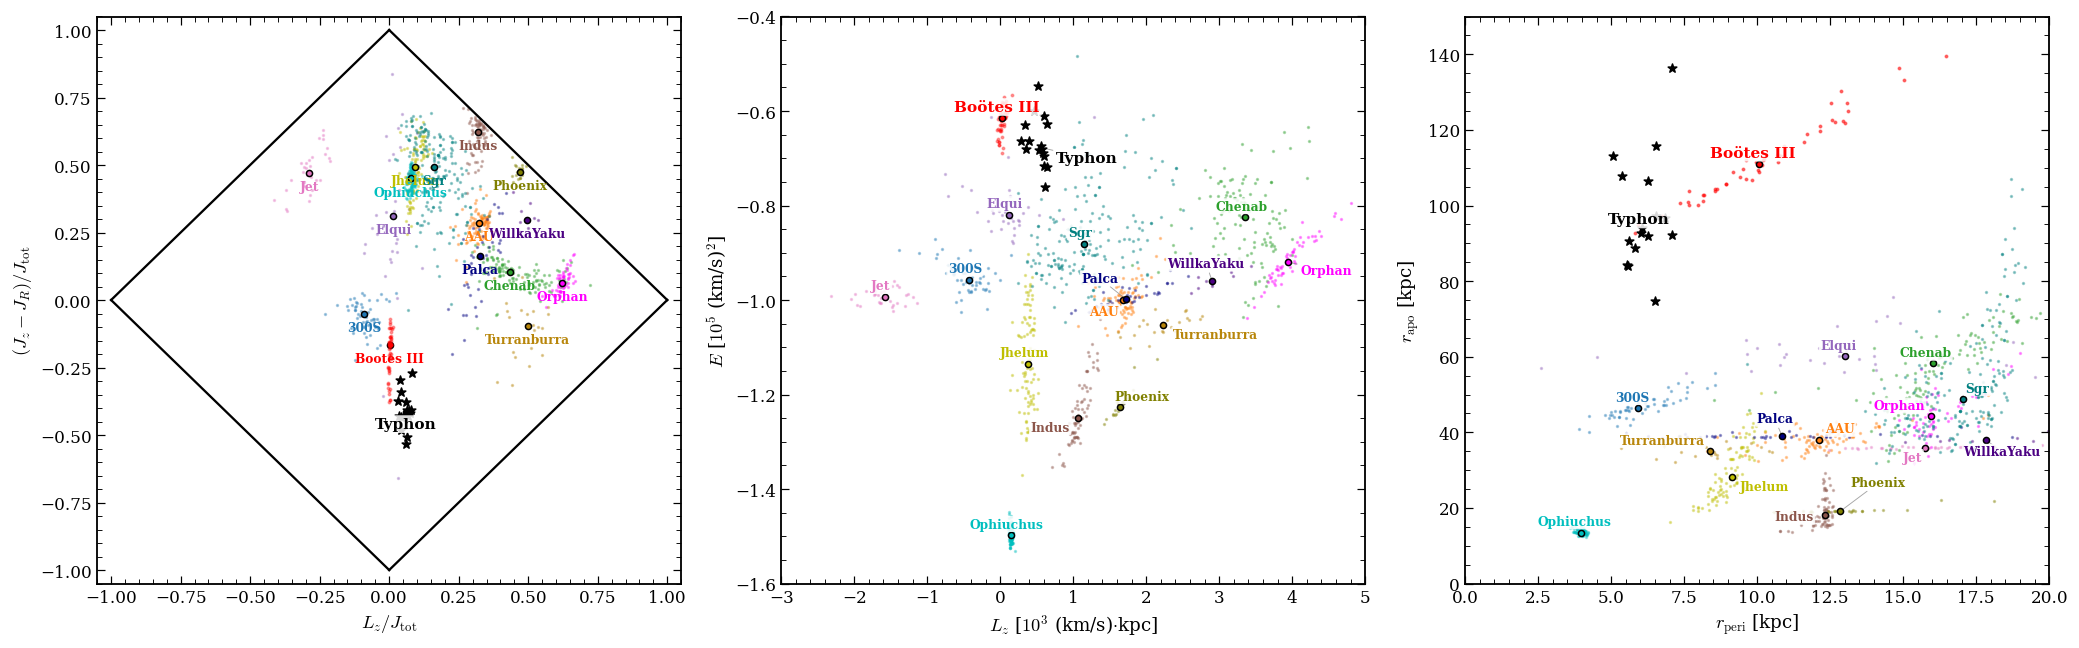

In [7]:
print("Plotting Fig 9 ...")

def _smart_place_v(ax, x, y, name, placed, sx, sy, base_yoff_norm,
                    color, fontsize=8, fontweight="bold", bbox=None,
                    extra_anchors=(), x_range=None, y_range=None):
    """Aggressive label placement: tries a dense grid of (dx, dy, ha)
    offsets centred on the marker, picking the first that avoids both
    placed labels and extra_anchors (markers).  The horizontal/vertical
    step grows as sqrt(N_failures) so cluttered regions can reach
    empty space several panel-units away."""
    base_y = base_yoff_norm * sy
    base_x = base_yoff_norm * sx * 2.0
    # Build a generous trial list.  First a small set of nearby positions,
    # then progressively larger horizontal shifts (with both alignments)
    # so wide labels in dense clusters can hop into empty space.
    trials = [
        (0.0,    +1.0, "center"),
        (0.0,    -1.4, "center"),
        (+1.5,    0.0, "left"),
        (-1.5,    0.0, "right"),
        (+1.5,   +0.6, "left"),
        (-1.5,   +0.6, "right"),
        (+1.5,   -0.9, "left"),
        (-1.5,   -0.9, "right"),
        (0.0,    +2.2, "center"),
        (0.0,    -2.4, "center"),
        (+3.0,    0.0, "left"),
        (-3.0,    0.0, "right"),
        (+3.0,   +0.8, "left"),
        (-3.0,   +0.8, "right"),
        (+3.0,   -1.1, "left"),
        (-3.0,   -1.1, "right"),
        (+5.0,    0.0, "left"),
        (-5.0,    0.0, "right"),
        (+5.0,   +1.5, "left"),
        (-5.0,   +1.5, "right"),
        (+5.0,   -1.8, "left"),
        (-5.0,   -1.8, "right"),
        (+8.0,    0.0, "left"),
        (-8.0,    0.0, "right"),
    ]
    chosen = None
    for dx_n, dy_n, ha in trials:
        nx = x + dx_n * base_x
        ny = y + dy_n * base_y
        if x_range is not None and not (x_range[0] <= nx <= x_range[1]):
            continue
        if y_range is not None and not (y_range[0] <= ny <= y_range[1]):
            continue
        too_close = False
        # Tighter exclusion radius vs other labels.
        for (px, py) in placed:
            if abs(nx-px)/sx < 0.06 and abs(ny-py)/sy < 0.035:
                too_close = True; break
        # Tighter exclusion radius vs marker positions (avoid covering them).
        if not too_close:
            for (px, py) in extra_anchors:
                if abs(nx-px)/sx < 0.045 and abs(ny-py)/sy < 0.030:
                    too_close = True; break
        if not too_close:
            chosen = (nx, ny, ha); break
    if chosen is None:
        # No collision-free spot found anywhere on the panel — place at
        # the smallest above-marker offset and accept some overlap.
        chosen = (x, y + base_y, "center")
    nx, ny, ha = chosen
    ax.text(nx, ny, name, ha=ha, c=color, fontsize=fontsize,
            fontweight=fontweight, clip_on=True, bbox=bbox, zorder=20)
    placed.append((nx, ny))


from adjustText import adjust_text
_lz_texts, _pa_texts = [], []
_lz_anchor_xy, _pa_anchor_xy = [], []
_placed_lz, _placed_pa = [], []   # legacy, retained for any other refs
_bbox = dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.85)
# Pre-compute every stream's marker centroid in panels 1 and 2 — labels
# will avoid these positions in addition to other already-placed labels.
_stream_marker_xy_lz = []
_stream_marker_xy_pa = []
for _n, _s in stream_data.items():
    _xlz_med = float(np.median(_s["actions"][1] / 1e3))
    _ye_med  = float(np.median(_s["energies"] / 1e5))
    _stream_marker_xy_lz.append((_xlz_med, _ye_med))
    _xp_med  = float(np.median(_s["peris"]))
    _ya_med  = float(np.median(_s["apos"]))
    _stream_marker_xy_pa.append((_xp_med, _ya_med))
fig, ax = plt.subplots(1, 3, figsize=(19, 6))
dotsize = 4
alpha = 0.35
# Excluding tab:red and tab:gray/black — those are reserved for Boo III
# (red) and Typhon (black) so no stream gets visually confused with them.
color_pool = cycle(["tab:blue", "tab:orange", "tab:green", "tab:purple",
                    "tab:brown", "tab:pink", "y", "c",
                    "magenta", "navy", "olive", "teal",
                    "darkgoldenrod", "indigo"])

for side in [([-1, 0], [0, -1]), ([0, 1], [-1, 0]), ([1, 0], [0, 1]), ([0, -1], [1, 0])]:
    ax[0].plot(side[0], side[1], c="k", zorder=2)
ax[0].set_xlabel(r"$L_z / J_{\rm tot}$")
ax[0].set_ylabel(r"$(J_z - J_R) / J_{\rm tot}$")

# Boo III + Typhon centres in the (Lz, E) and (peri, apo) panels.
_boo_lz, _boo_e   = float(np.median(boo_a[1]/1e3)), float(np.median(boo_E/1e5))
_boo_pe, _boo_ap  = float(np.median(boo_peri)),     float(np.median(boo_apo))
_typ_lz = typ_acts[1]/1e3 if typ_acts.size > 0 else np.array([])
_typ_e  = typ_E/1e5      if typ_acts.size > 0 else np.array([])
_typ_pe = typ_peri       if typ_acts.size > 0 else np.array([])
_typ_ap = typ_apo        if typ_acts.size > 0 else np.array([])

def _near(x, y, anchors_x, anchors_y, sx, sy, thresh=0.18):
    if len(anchors_x) == 0: return False
    d = np.hypot((x - np.asarray(anchors_x)) / sx,
                 (y - np.asarray(anchors_y)) / sy)
    return float(d.min()) < thresh

_label_idx = 0
for name, s in stream_data.items():
    clr = next(color_pool)
    plot_diamond(ax[0], s["actions"], text=name, c=clr, marker=".", s=6, alpha=alpha, zorder=1)
    xlz = s["actions"][1] / 1e3; yE = s["energies"] / 1e5
    ax[1].scatter(xlz, yE, c=clr, alpha=alpha, marker=".", s=6, rasterized=True)
    mx, my = np.median(xlz), np.median(yE)
    ax[1].plot(mx, my, "o", ms=dotsize, c=clr, mec="k")
    # Panel 1 — show ALL streams; pass all stream-marker centroids so the
    # label avoids the symbols, not just other labels.
    _t = ax[1].text(mx, my, name, ha="center", c=clr, fontsize=8,
                    fontweight="bold", clip_on=True, bbox=_bbox, zorder=20)
    _lz_texts.append(_t); _lz_anchor_xy.append((mx, my))
    xp, ya = s["peris"], s["apos"]
    ax[2].scatter(xp, ya, c=clr, alpha=alpha, marker=".", s=6, rasterized=True)
    mx, my = np.median(xp), np.median(ya)
    ax[2].plot(mx, my, "o", ms=dotsize, c=clr, mec="k")
    # Panel 2 — show ALL streams.
    _t = ax[2].text(mx, my, name, ha="center", c=clr, fontsize=8,
                    fontweight="bold", clip_on=True, bbox=_bbox, zorder=20)
    _pa_texts.append(_t); _pa_anchor_xy.append((mx, my))
    _label_idx += 1

plot_diamond(ax[0], boo_a, text="Bootes III", c="red", marker=".", s=10, alpha=alpha, zorder=3)
ax[1].scatter(boo_a[1]/1e3, boo_E/1e5, c="red", marker=".", alpha=alpha, s=10)
mx, my = np.median(boo_a[1]/1e3), np.median(boo_E/1e5)
ax[1].plot(mx, my, "o", ms=dotsize, c="red", mec="k")
_t_boo = ax[1].text(mx, my, "Boötes III", ha="center", c="red",
              fontweight="bold", fontsize=10, clip_on=True, bbox=_bbox, zorder=22)
_lz_texts.append(_t_boo); _lz_anchor_xy.append((mx, my))
ax[2].scatter(boo_peri, boo_apo, c="red", marker=".", alpha=0.5, s=10)
mx, my = np.median(boo_peri), np.median(boo_apo)
ax[2].plot(mx, my, "o", ms=dotsize, c="red", mec="k")
_t_boo2 = ax[2].text(mx, my, "Boötes III", ha="center", c="red",
              fontweight="bold", fontsize=10, clip_on=True, bbox=_bbox, zorder=22)
_pa_texts.append(_t_boo2); _pa_anchor_xy.append((mx, my))

if typ_acts.size > 0:
    plot_diamond(ax[0], typ_acts, c="k", marker="*", s=35, zorder=3, text="")
    ax[1].scatter(typ_acts[1]/1e3, typ_E/1e5, c="k", marker="*", s=35, zorder=3, label="Typhon")
    ax[2].scatter(typ_peri, typ_apo, c="k", marker="*", s=35, zorder=3)
    # Centroid coords for the Typhon label.
    _Jt = np.abs(typ_acts[0]) + np.abs(typ_acts[1]) + np.abs(typ_acts[2])
    _typ0_x = float(np.median(typ_acts[1] / _Jt))
    _typ0_y = float(np.median((typ_acts[2] - typ_acts[0]) / _Jt))
    _typ1_x, _typ1_y = float(np.median(typ_acts[1]/1e3)), float(np.median(typ_E/1e5))
    _typ2_x, _typ2_y = float(np.median(typ_peri)),       float(np.median(typ_apo))
    # Panel 0 — direct ax[0].text (no smart-place dict here, just 1 label).
    ax[0].text(_typ0_x, _typ0_y - 0.06, "Typhon", ha="center", c="k",
               fontweight="bold", fontsize=10, clip_on=True, zorder=21,
               bbox=_bbox)
    _t_typ1 = ax[1].text(_typ1_x, _typ1_y, "Typhon", ha="center", c="k",
              fontweight="bold", fontsize=10, clip_on=True, bbox=_bbox, zorder=22)
    _lz_texts.append(_t_typ1); _lz_anchor_xy.append((_typ1_x, _typ1_y))
    _t_typ2 = ax[2].text(_typ2_x, _typ2_y, "Typhon", ha="center", c="k",
              fontweight="bold", fontsize=10, clip_on=True, bbox=_bbox, zorder=22)
    _pa_texts.append(_t_typ2); _pa_anchor_xy.append((_typ2_x, _typ2_y))

ax[0].set_xlim(-1.05, 1.05); ax[0].set_ylim(-1.05, 1.05)
ax[1].set_xlabel(r"$L_z$ [$10^3$ (km/s)$\cdot$kpc]")
ax[1].set_ylabel(r"$E$ [$10^5$ (km/s)$^2$]")
ax[1].set_xlim(-3, 5); ax[1].set_ylim(-1.6, -0.4)
ax[2].set_xlabel(r"$r_{\rm peri}$ [kpc]")
ax[2].set_ylabel(r"$r_{\rm apo}$ [kpc]")
ax[2].set_xlim(0, 20); ax[2].set_ylim(0, 150)

# Repulsion-based label placement via adjustText: shifts each label off
# both other labels and marker points, drawing a thin grey leader if a
# label has to move far from its marker.
import numpy as _np
def _xy_arr(pairs):
    if not pairs: return None, None
    a = _np.asarray(pairs); return a[:, 0], a[:, 1]
_lz_x, _lz_y = _xy_arr(_lz_anchor_xy)
adjust_text(_lz_texts, x=_lz_x, y=_lz_y, ax=ax[1],
            force_text=(0.5, 0.7), force_static=(0.4, 0.5),
            expand=(1.2, 1.4),
            arrowprops=dict(arrowstyle="-", color="0.5", lw=0.6, alpha=0.7))
_pa_x, _pa_y = _xy_arr(_pa_anchor_xy)
adjust_text(_pa_texts, x=_pa_x, y=_pa_y, ax=ax[2],
            force_text=(0.5, 0.7), force_static=(0.4, 0.5),
            expand=(1.2, 1.4),
            arrowprops=dict(arrowstyle="-", color="0.5", lw=0.6, alpha=0.7))

plt.tight_layout()
out_pdf = FIG_DIR / "fig10_typhon_streams.pdf"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
print(f"Saved {out_pdf}")
plt.show()


## 4 · Section C — Figure 11 (Boo III fiducial spray vs Sgr stream)

Loads the fiducial spray from notebook 2's `output/spray_cache_new6D/`, finds
the file matching `spray_fid_*.pkl`, and overlays its particles on the
Vasiliev+21 Sgr stream catalogue in (Dec, $\mu_\alpha\cos\delta$,
$\mu_\delta$, RV, DM) vs RA. The overlap in sky+PM but separation in
RV+DM is the central message: spectroscopy can disentangle the two.


In [8]:
# Find the fid spray pkl from notebook 2
fid_pkl = CACHE_DIR / "spray_fid.pkl"
if not fid_pkl.exists():
    raise FileNotFoundError(
        f"{fid_pkl} not found. Run notebook 2 first.")
print(f"Using fiducial spray pkl: {fid_pkl.name}")
with open(fid_pkl, "rb") as f:
    fid = pickle.load(f)
p = fid["particles"]
r_ra    = np.asarray(p["ra"])
r_dec   = np.asarray(p["dec"])
r_pmra  = np.asarray(p["pmra"])
r_pmdec = np.asarray(p["pmdec"])
r_vlos  = np.asarray(p["vlos"])
r_dist  = np.asarray(p["dist"])
print(f"  {len(r_ra)} particles loaded")

# Vasiliev+21 Sgr fixed-width catalogue
print(f"Loading Vasiliev+21 Sgr ...")
cols = [
    ("ra",     1,   8,  float),
    ("dec",    10,  17, float),
    ("plx",    19,  24, float),
    ("plx_e",  26,  30, float),
    ("pmra",   32,  37, float),
    ("pmra_e", 39,  43, float),
    ("pmdec",  45,  50, float),
    ("pmdec_e",52,  56, float),
    ("G",      58,  62, float),
    ("BP",     64,  67, float),
    ("J",      69,  73, float),
    ("H",      75,  79, float),
    ("K",      81,  85, float),
    ("EBV",    87,  90, float),
    ("Dist",   92,  96, float),
    ("Dist_e", 98,  102, float),
    ("vLOS",   104, 110, float),
    ("vLOS_e", 112, 116, float),
    ("feh",    118, 122, float),
    ("feh_e",  124, 127, float),
    ("ref",    129, 129, str),
    ("Lambda", 131, 138, float),
    ("Beta",   140, 146, float),
]
colspecs = [(c[1]-1, c[2]) for c in cols]
names    = [c[0] for c in cols]
sgr = pd.read_fwf(SGR_DAT, colspecs=colspecs, names=names, na_values=[""])
sgr_data = sgr.rename(columns={"vLOS": "vlos", "Dist": "dist"})
print(f"  {len(sgr_data):,} Sgr stars")


Using fiducial spray pkl: spray_fid.pkl


  2000 particles loaded
Loading Vasiliev+21 Sgr ...


  55,192 Sgr stars


Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/fig11_sgr_and_boo3.pdf


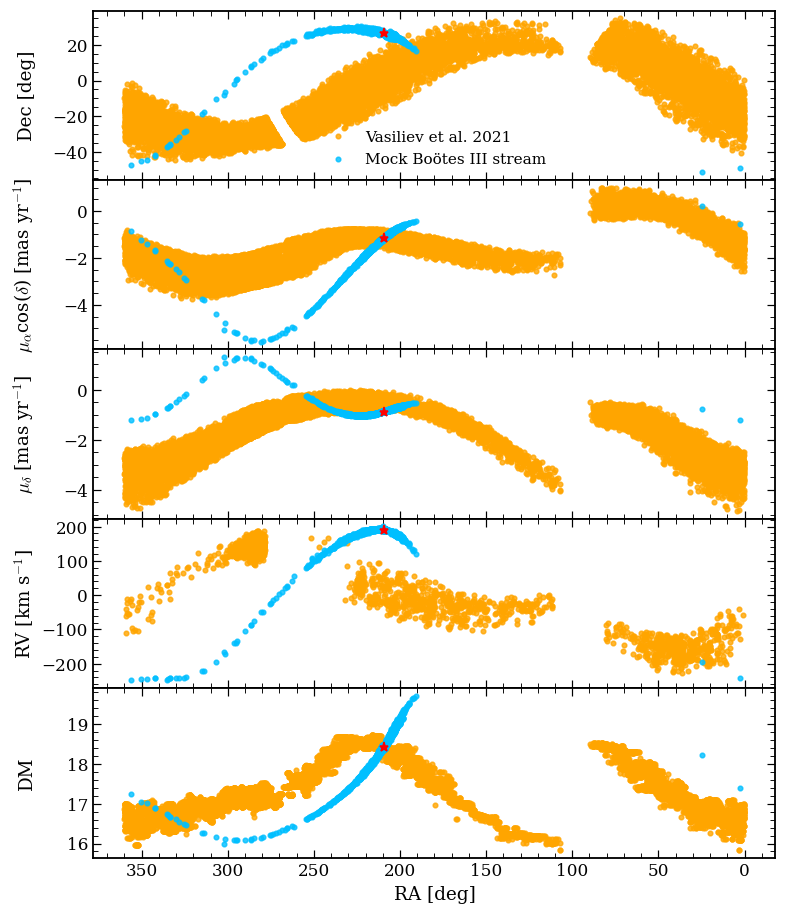

In [9]:
def distance_to_dm(d_pc):
    return 5 * np.log10(d_pc / 10.0)


def plot_sgr_data(ax, sgr_data):
    ax[0].plot(sgr_data['ra'], sgr_data['dec'], '.', c='orange',
               label='Vasiliev et al. 2021', alpha=0.8, zorder=1, rasterized=True)
    ax[1].plot(sgr_data['ra'], sgr_data['pmra'], '.', c='orange',
               alpha=0.8, zorder=1, rasterized=True)
    ax[2].plot(sgr_data['ra'], sgr_data['pmdec'], '.', c='orange',
               alpha=0.8, zorder=1, rasterized=True)
    ax[3].plot(sgr_data['ra'], sgr_data['vlos'], '.', c='orange',
               alpha=0.8, zorder=1, rasterized=True)
    ax[4].plot(sgr_data['ra'], distance_to_dm(sgr_data['dist'] * 1000),
               '.', c='orange', alpha=0.8, zorder=1, rasterized=True)


def plot_boo3_particles(ax, ra, dec, pmra, pmdec, vlos, dist, **kwargs):
    ax[0].scatter(ra, dec, marker='.', alpha=0.8, label="Mock Boötes III stream",
                  **kwargs, rasterized=True)
    ax[1].scatter(ra, pmra,  marker='.', alpha=0.8, **kwargs, rasterized=True)
    ax[2].scatter(ra, pmdec, marker='.', alpha=0.8, **kwargs, rasterized=True)
    ax[3].scatter(ra, vlos,  marker='.', alpha=0.8, **kwargs, rasterized=True)
    ax[4].scatter(ra, distance_to_dm(1000 * dist), marker='.', alpha=0.8,
                  **kwargs, rasterized=True)


pmra_label  = r'$\mu_{\alpha}$cos($\delta$) [mas yr$^{-1}$]'
pmdec_label = r'$\mu_{\delta}$ [mas yr$^{-1}$]'

fig, ax = plt.subplots(5, 1, sharex=True, figsize=(8, 10))
fig.subplots_adjust(hspace=0)
plot_sgr_data(ax, sgr_data)
plot_boo3_particles(ax, r_ra, r_dec, r_pmra, r_pmdec, r_vlos, r_dist,
                    c='deepskyblue', zorder=2)

labels  = ["Dec [deg]", pmra_label, pmdec_label,
           r"RV [km s$^{-1}$]", "DM"]
prog_y  = [DEC_BOO3, PMRA_BOO3, PMDEC_BOO3, VEL_BOO3,
           distance_to_dm(DIST_BOO3 * 1000)]
for ax_i, lbl, val in zip(ax, labels, prog_y):
    ax_i.plot(RA_BOO3, val, "*r")
    ax_i.set_ylabel(lbl, fontsize=12)
    ax_i.invert_xaxis()
ax[4].set_xlabel("RA [deg]", fontsize=12)
ax[0].legend(loc='lower center', fontsize=10)
fig.align_ylabels(ax)
out_pdf = FIG_DIR / "fig11_sgr_and_boo3.pdf"
fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
print(f"Saved {out_pdf}")
plt.show()


---

**Outputs of this notebook**

| file | content |
|:--|:--|
| `figures/fig9_typhon_dwarfs.pdf`     | Boo III vs Typhon vs LVDB dwarfs |
| `figures/fig10_typhon_streams.pdf`    | Boo III vs Typhon vs S5 streams |
| `figures/fig11_sgr_and_boo3.pdf`     | Boo III fiducial spray vs Sgr stream |
